# Fluconazole dose–response and IC20

This notebook analyzes endpoint OD readings from the pooled HIP assay. Because the file contains concentrations rather than time points, the plotted curve is a **dose–response curve**. IC20 is defined here as the fluconazole concentration at which blank-corrected OD is **80% of the untreated control**.

Each `Rep` column is treated as one paired replicate across concentrations, its blank, and its untreated control. The plot shows mean ± SD of the normalized replicate readings and a 95% bootstrap confidence band for the fitted mean curve. The band and IC20 interval resample whole replicate columns so the within-replicate pairing is preserved.

The inhibitory Hill fit below has a free upper plateau and a lower plateau fixed at zero. Complete inhibition is not observed at the highest tested concentration, so the lower plateau is an assumption. The IC20 estimate is an interpolation within the tested range; the notebook reports the model and bootstrap uncertainty explicitly.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from IPython.display import display

DATA_PATH = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Pooled/MIC/FLC_MIC_0916.csv")
N_BOOT = 2000
RANDOM_SEED = 20260917
TARGET_GROWTH = 0.80

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Set DATA_PATH to the location of FLC_MIC_0916.csv: {DATA_PATH}")

In [2]:
raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
label_col = raw.columns[0]
rep_cols = list(raw.columns[1:])
if len(rep_cols) < 2:
    raise ValueError("At least two replicate columns are needed for uncertainty estimates.")

labels = raw[label_col].astype(str).str.strip().str.lower()
blank_rows = labels.eq("blank")
control_rows = labels.eq("0")
if blank_rows.sum() != 1 or control_rows.sum() != 1:
    raise ValueError("Expected exactly one 'Blank' row and one '0' untreated-control row.")

od = raw[rep_cols].apply(pd.to_numeric, errors="coerce")
concentration = pd.to_numeric(raw[label_col], errors="coerce")
positive_rows = concentration.notna() & concentration.gt(0)
if positive_rows.sum() < 4:
    raise ValueError("At least four positive concentrations are needed for this fit.")
if od.loc[positive_rows | blank_rows | control_rows].isna().any().any():
    raise ValueError("OD values are missing or nonnumeric in rows used for the analysis.")

blank = od.loc[blank_rows].iloc[0].to_numpy(dtype=float)
control = od.loc[control_rows].iloc[0].to_numpy(dtype=float)
control_corrected = control - blank
if np.any(control_corrected <= 0):
    raise ValueError("Every untreated control must exceed its matching blank.")

order = np.argsort(concentration.loc[positive_rows].to_numpy(dtype=float))
doses = concentration.loc[positive_rows].to_numpy(dtype=float)[order]
if np.unique(doses).size != doses.size:
    raise ValueError("Positive concentration rows must be unique; combine duplicate rows first.")
od_positive = od.loc[positive_rows].to_numpy(dtype=float)[order]
growth = (od_positive - blank[None, :]) / control_corrected[None, :]

summary = pd.DataFrame({
    "FLC (µg/mL)": doses,
    "mean relative growth": growth.mean(axis=1),
    "SD across replicates": growth.std(axis=1, ddof=1),
    "n": growth.shape[1],
})
print(f"Loaded {growth.shape[1]} paired replicates at {growth.shape[0]} positive concentrations.")
display(summary)

Loaded 8 paired replicates at 10 positive concentrations.


,FLC (µg/mL),mean relative growth,SD across replicates,n
0,0.390625,0.959815,0.051198,8
1,0.781250,0.949683,0.064629,8
2,1.562500,0.948503,0.054336,8
3,3.125000,0.917047,0.052366,8
4,6.250000,0.890792,0.095699,8
5,12.500000,0.885068,0.048118,8
6,25.000000,0.868145,0.059464,8
7,50.000000,0.767095,0.061411,8
8,100.000000,0.674832,0.046299,8
9,200.000000,0.548081,0.046852,8


In [3]:
def hill_growth(x, top, scale, slope):
    # Zero lower asymptote; concentrations and scale have the same units.
    return top / (1.0 + (np.asarray(x) / scale) ** slope)


def fit_hill(observations, initial=None):
    if initial is None:
        initial = [1.0, float(np.median(doses)), 1.0]
    bounds = ([0.850001, doses.min() / 1000, 0.1],
              [1.2, doses.max() * 1000, 5.0])
    result = least_squares(
        lambda p: (hill_growth(doses[:, None], *p) - observations).ravel(),
        x0=initial, bounds=bounds, max_nfev=5000,
    )
    if not result.success:
        raise RuntimeError(f"Hill fit failed: {result.message}")
    return result.x


def concentration_at_growth(params, target=TARGET_GROWTH):
    top, scale, slope = params
    if not 0 < target < top:
        raise ValueError("Target growth must lie below the fitted upper plateau.")
    return scale * (top / target - 1.0) ** (1.0 / slope)


fit_params = fit_hill(growth)
ic20 = concentration_at_growth(fit_params)
print(f"Hill parameters: upper plateau = {fit_params[0]:.3f}, "
      f"scale = {fit_params[1]:.2f} µg/mL, slope = {fit_params[2]:.3f}")
print(f"Fitted IC20 = {ic20:.2f} µg/mL")
if not doses.min() <= ic20 <= doses.max():
    print("Caution: IC20 lies outside the tested concentration range.")

Hill parameters: upper plateau = 0.953, scale = 290.58 µg/mL, slope = 0.832
Fitted IC20 = 39.63 µg/mL


In [4]:
# Resample paired replicate columns, then refit each bootstrap sample.
rng = np.random.default_rng(RANDOM_SEED)
x_grid = np.geomspace(doses.min(), doses.max(), 400)
bootstrap_curves = np.empty((N_BOOT, x_grid.size))
bootstrap_ic20 = np.empty(N_BOOT)

for b in range(N_BOOT):
    sampled_cols = rng.integers(0, growth.shape[1], size=growth.shape[1])
    params_b = fit_hill(growth[:, sampled_cols], initial=fit_params)
    bootstrap_curves[b] = hill_growth(x_grid, *params_b)
    bootstrap_ic20[b] = concentration_at_growth(params_b)

curve_lower, curve_upper = np.quantile(bootstrap_curves, [0.025, 0.975], axis=0)
ic20_lower, ic20_upper = np.quantile(bootstrap_ic20, [0.025, 0.975])
print(f"IC20 95% bootstrap confidence interval: {ic20_lower:.2f}–{ic20_upper:.2f} µg/mL")

IC20 95% bootstrap confidence interval: 29.28–53.80 µg/mL


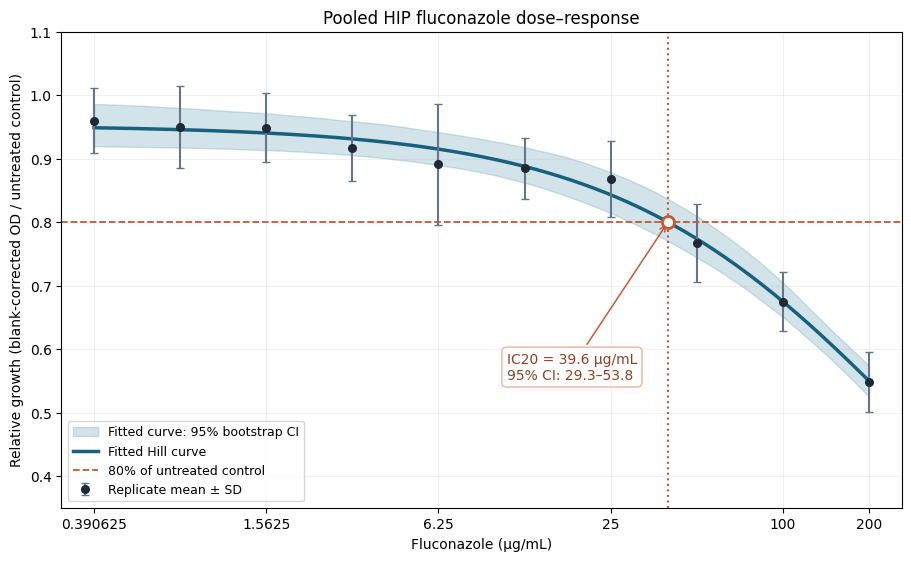

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
ax.fill_between(x_grid, curve_lower, curve_upper, color="#3B82A0", alpha=0.22,
                label="Fitted curve: 95% bootstrap CI")
ax.plot(x_grid, hill_growth(x_grid, *fit_params), color="#17617C", lw=2.5,
        label="Fitted Hill curve")
ax.errorbar(doses, summary["mean relative growth"],
            yerr=summary["SD across replicates"], fmt="o", ms=5.5,
            capsize=3, color="#1F2937", ecolor="#64748B",
            label="Replicate mean ± SD")
ax.axhline(TARGET_GROWTH, color="#C35A32", ls="--", lw=1.3,
           label="80% of untreated control")
ax.axvline(ic20, color="#C35A32", ls=":", lw=1.5)
ax.scatter([ic20], [TARGET_GROWTH], s=75, facecolor="white",
           edgecolor="#C35A32", linewidth=2, zorder=5)
ax.annotate(f"IC20 = {ic20:.1f} µg/mL\n95% CI: {ic20_lower:.1f}–{ic20_upper:.1f}",
            xy=(ic20, TARGET_GROWTH), xycoords="data",
            xytext=(0.53, 0.27), textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color="#C35A32", lw=1.1),
            fontsize=10, color="#913F20",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#E6B39F"))
ax.set_xscale("log", base=2)
ax.set_xlim(doses.min() / 1.3, doses.max() * 1.3)
shown_ticks = doses[[0, 2, 4, 6, 8, 9]]
ax.set_xticks(shown_ticks)
ax.set_xticklabels([f"{value:g}" for value in shown_ticks])
ax.set_ylim(0.35, 1.10)
ax.set_xlabel("Fluconazole (µg/mL)")
ax.set_ylabel("Relative growth (blank-corrected OD / untreated control)")
ax.set_title("Pooled HIP fluconazole dose–response")
ax.grid(True, which="major", alpha=0.18)
ax.legend(loc="lower left", frameon=True, fontsize=9)
plt.show()

**Reading the plot.** Error bars are the standard deviation of the eight normalized replicates at each concentration. The shaded area is a pointwise 95% confidence interval for the fitted mean curve from replicate bootstrap resampling; it is not a prediction interval for a new replicate. The IC20 interval uses the same bootstrap fits. This measures variability among the available replicates and does not account for differences between assay days or batches.